# 01. Integral norms: estimators and convergence

**Question:** given samples of a path, how should the integral norm be estimated?

---

## 0. Setting

### 0.1 Problem

Let $f:[0,T]\to\mathbb{R}^d$ be the function whose norm is wanted, sampled at $t_0 < \cdots < t_N$, so $N+1$ points and $N$ intervals. Estimate

$$\|f\|_{L^p} = \Big(\int_0^T |f|^p\Big)^{1/p} .$$

Write $g = |f|^p$ for the **integrand**, so the target and its estimator are

$$I(g) = \int_0^T g , \qquad Q_w(g) = \sum_{i=0}^N w_i\, g(t_i) .$$

Note that $f$ is the sampled function, $g$ is argument of the quadrature rule and their smoothness differs. For odd $p$, $g = |f|^p$ has a kink at every zero of $f$ however smooth $f$ is, and it is $g$ that the error bounds constrain.

The sample times $t_i$ are given, not chosen, so the question is the choice of $w$. Two choices recur (trapezoid and uniform):

$$w^{\mathrm{trap}}_i = \tfrac12(\Delta t_{i-1} + \Delta t_i), \qquad w^{\mathrm{unif}}_i = \tfrac{T}{N+1},
\qquad \Delta t_i = t_{i+1}-t_i \ \ (0 \le i \le N-1) ,$$

with $\Delta t_{-1} = \Delta t_N = 0$, so that the endpoints carry half weight:

$$w^{\mathrm{trap}}_0 = \tfrac12\Delta t_0, \qquad w^{\mathrm{trap}}_N = \tfrac12\Delta t_{N-1} .$$

Each $t_i$ is weighted by the length of the interval for which it is the nearest sample, and the endpoints have interval on one side only. Both vectors sum to $T$:

Write $Q^{\mathrm{trap}}$ and $Q^{\mathrm{unif}}$ for the corresponding rules. Pointwise MSE is equivalent to the quadrature rule with uniform weights, since

$$\mathrm{MSE} = \frac{1}{N+1}\sum_i f(t_i)^2 = \tfrac1T\,Q^{\mathrm{unif}}(f^2) .$$

§2 and §3 ask when each converges to $I(g)$.

**In the loss application** $f = \hat y - y$, the residual between a prediction and a path.

### 0.2 Relation to the baseline loss

The baseline is pointwise MSE, i.e. $\tfrac1T Q^{\mathrm{unif}}(f^2)$. On a **uniform** grid $w^{\mathrm{unif}}$ and $w^{\mathrm{trap}}$ differ only at the two endpoints (§1.2), so both converge and

$$\mathrm{MSE} \;\xrightarrow[N\to\infty]{}\; \frac1T\int_0^T f^2 \;=\; \frac1T\|f\|_{L^2}^2 .$$

The integral norm is the continuum limit of MSE, not a rival to it. §3 shows this fails once the grid is not uniform.

### 0.3 Contents

| section | | result |
|---|---|---|
| §1 | Choice of weights | trapezoid |
| §2 | Convergence rates, quoted | quadrature error not a confounder |
| §3 | Non-uniform sampling | MSE converges to the wrong limit; weighting cannot fix lost information |
| §4 | Choice of $p$ | $p=2$, by Lyapunov |
| §5 | Conclusions | the estimator, the finding, what follows |
| §6 | Literature | §§1 and 2 standard, §3 is Horvitz-Thompson |

The ML literature on irregularly sampled data (Che et al., 2018; Rubanova et al., 2019; Shukla & Marlin, 2021; Kidger et al., 2020) modifies the model to ingest irregular observations, leaving the objective as pointwise MSE. §6.5.

> **Parallel with sFML.** There, a uniform average over a non-uniformly visited *state* space; here, over a non-uniformly sampled *time* axis.

## 1. Choice of weights

### 1.1 Quadrature rules

Write $\Delta t_i = t_{i+1} - t_i$ for the gaps. Each rule replaces $g$ on a subinterval by an interpolating polynomial and integrates that exactly.

| rule | interpolant | weights |
|---|---|---|
| left Riemann | degree 0, left endpoint | $w_i = \Delta t_i$, $w_n=0$ |
| **trapezoid** | degree 1, both endpoints | $w_i = \tfrac12(\Delta t_{i-1} + \Delta t_i)$, half weight at $t_0, t_N$ |
| Simpson | degree 2, three points | $\tfrac{1}{3}\Delta t\,(1,4,2,\dots,4,1)$, uniform $\Delta t$ |
| Gauss-Legendre | chooses nodes | weights at roots of the Legendre polynomial $P_n$ |

Simpson's row carries a single spacing because it presupposes a uniform grid; the other rules need no such assumption.


### 1.2 Degree of exactness

An interpolatory rule is exact for polynomials up to the degree of its interpolant (Davis & Rabinowitz, 1984, §2.1). For trapezoid this is degree 1, and the argument is local to each subinterval, so it holds on any grid.

Equal weights $w^{\mathrm{unif}}$ are exact on constants but not on lines, unless the nodes are symmetric about the midpoint. Both in `test_trapezoid_on_constants_and_lines` and `test_uniform_weights_on_constants_and_lines`.

### 1.3 Error

Standard (Davis & Rabinowitz, 1984): with $h_{\max} = \max_i \Delta t_i$, for $g \in C^2$,

$$\big|I(g) - Q_w(g)\big| \;\le\; \tfrac{T}{12}\,h_{\max}^2\,\|g''\|_\infty ,$$

obtained by summing the local error $-\tfrac1{12}h_i^3 g''(\xi_i)$. Accuracy is limited by curvature and by the widest gap. §2 takes up the case $\|g''\|_\infty = \infty$.

### 1.4 Availability

| rule | exact to degree | requires |
|---|---|---|
| left Riemann | 0 | nothing |
| **trapezoid** | **1** | **nothing** |
| Simpson | 3 | uniform spacing, odd number of points |
| Gauss-Legendre | $2N-1$ | control of node positions |

Simpson's weights are derived with the middle node at the midpoint; on unequal spacing the coefficients change per triple, so the standard formula is a different rule rather than an inaccurate one. Gauss-Legendre requires choosing where to sample.

In a general setting with fixed nodes, **Trapezoid is adopted**. Simpson and Gauss-Legendre may appear later as reference values on grids we control. Error terms as in Davis & Rabinowitz (1984).

### 1.5 Cost: bias against variance

The weights are chosen to remove a bias. Assume that $Y_i = g(t_i) + \varepsilon_i$ with $\operatorname{Var}(\varepsilon_i) = \sigma^2$ independent. Normalise $\tilde w_i = w_i/\sum_j w_j$; then

$$\operatorname{Var}\Big(\sum_i \tilde w_i Y_i\Big) = \sigma^2 \sum_i \tilde w_i^{\,2},
\qquad \sum_i \tilde w_i^{\,2} \ge \frac1{N+1} \quad\text{(Cauchy-Schwarz)},$$

with equality iff all weights are equal.

> Equal weights minimise variance. Trapezoid weights minimise bias. Nothing does both.

**Effective sample size.** An unweighted average of $\nu$ observations has variance $\sigma^2/\nu$. Setting $\sigma^2/\nu = \sigma^2\sum_i \tilde w_i^{\,2}$ gives Kish's

$$n_{\mathrm{eff}} = \frac{1}{\sum_i \tilde w_i^{\,2}} \le N+1 :$$

the weighted estimator is as noisy as an unweighted average of $n_{\mathrm{eff}}$ observations. Weight concentrated on a few points means the rest contribute little. Equal weights give $n_{\mathrm{eff}} = N+1$; all weight on one point gives $n_{\mathrm{eff}} = 1$. On the §3 grids, 120 points:

| grid | $n_{\mathrm{eff}}$ | variance inflation | $w_{\max}/w_{\min}$ |
|---|---|---|---|
| uniform | 119.5 | $1.00\times$ | 2.0 |
| clustered, $t = u^{0.35}$ | 30.7 | $3.91\times$ | 81.1 |

Zhang & Wang (2016) show the preferable weighting reverses with sampling density; Godambe (1955) proved no best linear unbiased estimator exists even under simple random sampling, so the absence of an unconditional recommendation is a theorem rather than a gap.

Nothing in this notebook contains noise: §3 evaluates deterministic functions, so the variance term is zero there and the bias governs. The cost above is recorded for future reference.

Noise also adds a bias. With $p=2$, $\mathbb{E}[Q_w(Y^2)] = \int_0^T f^2 + \sigma^2 T + O(h_{\max}^2)$, using $\sum_j w_j = T$; the term $\sigma^2 T$ does not depend on $w$. Removing it requires smoothing before integrating (Ramsay & Silverman, 2005, ch. 3 to 5).

### 1.6 Conclusion

$$\|f\|_{L^p}^p \;\approx\; \sum_{i=0}^N w^{\mathrm{trap}}_i\,|f(t_i)|^p, \qquad w^{\mathrm{trap}} \text{ as in §0.1},$$

implemented as `integral_norm(t, x, p)` and `integral_distance(t, x, y, p)`.

**Scope.** 
Among rules requiring no assumption on $f$ and no control of the node positions, trapezoid has the highest degree of exactness (§1.2). It is also Bayes-optimal under a continuity prior and unbiased under any sampling design (§1.5). It is the default surviving the fewest assumptions, not an optimum: Godambe (1955) rules out an unconditional best linear unbiased estimator, equal weights win on variance (§1.6), splines win given differentiability, and smoothing before integrating wins given observation noise.

§3 does not depend on the choice. Any consistent estimator of $\int f^2$ shows the same failure of equal weights.

Carried forward: adopt trapezoid; make no noise-robustness claim; report $n_{\mathrm{eff}}$ with every loss value.

In [1]:
%matplotlib inline
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# `pathloss` comes from `pip install -e .`; this line also makes the notebook
# work without it.
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

from pathloss.norms import integral_norm, integral_distance, pointwise_mse
from pathloss.paths import brownian_motion

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (10, 3.6), "figure.dpi": 110})

## 2. Convergence rate (uniform grid)

§1 chose the weights. §2 fixes the sample budget, so that §3 cannot be attributed to quadrature error. This section details the rate at which error decreases as the grid is refined

Throughout this section the grid is **uniform**, with spacing $h = T/N$ over the $N$ intervals. On a uniform grid $w^{\mathrm{unif}}$ and $w^{\mathrm{trap}}$ differ only at the endpoints, so the statements below cover both rules and the choice of weights is invisible. §3 removes the restriction, and the two separate.

**Rates.** For $g \in C^2$, trapezoid is $O(h^2)$ and left-Riemann $O(h)$; Davis & Rabinowitz (1984), §2.1 and §2.4. Regressing $\log(\text{error})$ on $\log N$ for $f(t)=e^t$, against its closed-form norm, gives gradients $-2.01$ and $-1.01$: the code attains the stated orders. `test_convergence_rates_on_non_periodic_integrand`.

**Euler-Maclaurin.** Truncating at $M$ terms,

$$\int_a^b g \;=\; h\Big[\tfrac12 g_0 + \cdots + \tfrac12 g_N\Big] \;-\; \sum_{k=1}^{M}\frac{B_{2k}}{(2k)!}\,h^{2k}\Big[g^{(2k-1)}(b) - g^{(2k-1)}(a)\Big] \;+\; R_m ,
\qquad |R_M| \;\le\; \frac{2\zeta(2M)}{(2\pi)^{2M}}\,h^{2M}\int_a^b \big|g^{(2M)}\big| ,$$

with $B_{2k}$ the Bernoulli numbers. Each retained term is a difference of odd derivatives at the endpoints, so for smooth periodic $g$ every one vanishes and only $R_M$ survives, for every $M$: convergence exceeds any power of $h$ (Trefethen & Weideman, 2014). A convergence test on a periodic integrand therefore measures nothing, which rules out $\sin^2$ and is why $e^t$ is used. `test_trapezoid_on_smooth_periodic_integrand`.

**Without $C^2$.** The bound is vacuous for a nowhere-differentiable $g$, and a deterministic $\alpha$-Hölder bound gives only $O(N^{-\alpha})$. For Brownian $W$ that would be $O(N^{-1/2})$, but the per-interval errors are mean-zero Brownian bridge integrals of variance $\Theta(h^3)$, so summing $N$ independent terms gives $\Theta(h^2)$ in variance and an error of order $N^{-1}$: one order worse than the smooth case, not two. Heuristic, not a proof.

**Budget.** A few hundred samples for smooth $g$, where the quadrature error is $O(10^{-6})$ at $N \gtrsim 500$; $10^3$ to $10^4$ for a rough one. Either way four or more orders below the effects §3 measures, so quadrature error is controllable by sampling more densely. §3 turns to an error that is not.

## 3. Non-uniform sampling

§2 bounded $|Q_w(g) - I(g)|$ at finite $N$, which vanishes as the grid refines. This section concerns $\lim_m \mathrm{MSE} - \frac1T\int_0^T f^2$, which does not.

**Setup.** For $m = 1, 2, \dots$ let $\mathcal{T}_m = \{0 = t_0^{(m)} < \cdots < t_{N_m}^{(m)} = T\}$, with $N_m$ intervals, mesh $h_m = \max_i \Delta t_i^{(m)}$ and empirical measure $\mu_m = \frac{1}{N_m+1}\sum_i \delta_{t_i^{(m)}}$. The two rules of §0.1, applied to this grid, are

$$Q^{\mathrm{trap}}_m(g) = \sum_i w^{\mathrm{trap}}_i\, g\big(t_i^{(m)}\big),
\qquad
Q^{\mathrm{unif}}_m(g) = \frac{T}{N_m+1}\sum_i g\big(t_i^{(m)}\big) = T\!\int_0^T g\,\mathrm{d}\mu_m ,$$

and $\mathrm{MSE} = \tfrac1T Q^{\mathrm{unif}}_m(f^2)$. Both are instances of $Q_w$; only the weights differ.

**Method.** §3.1 further details the two limits. §3.2 fixes a $\rho$ realising the hypothesis of the second. §3.3 records that the propositions are standard and checked once in the test suite. §3.4 carries the only computation: the size of the gap at a realistic grid, and what happens when the hypotheses fail. §3.5 restates the result in the Lebesgue form, which is shorter and carries a warning.

### 3.1 The two limits

**Proposition 1.** *Let $g \in C([0,T])$. If $h_m \to 0$ then $Q^{\mathrm{trap}}_m(g) \to \int_0^T g$.*

Consistency of the trapezoid rule for continuous integrands. The hypothesis constrains only the mesh, not the placement of the nodes within it.

**Proposition 2.** *Let $g \in C([0,T])$ and suppose $\mu_m \Rightarrow \mu$ weakly, where $\mathrm{d}\mu = \rho\,\mathrm{d}t$ for a probability density $\rho$ on $[0,T]$. Then $Q^{\mathrm{unif}}_m(g) \to T\!\int_0^T g\rho$.*

Immediate from $Q^{\mathrm{unif}}_m(g) = T\!\int g\,\mathrm{d}\mu_m$ and the definition of weak convergence. Both constructions of §3.2 satisfy the hypothesis: independent draws from $\rho$ by the strong law, and the quantile grid because $\tfrac{1}{N_m+1}\sum_i (g\circ F^{-1})(u_i)$ is a Riemann sum for $\int_0^1 g\circ F^{-1} = \int_0^T g\rho$.

**Corollary.** *Let $f \in C([0,T])$ and let both hypotheses hold. Then*

$$\underbrace{\tfrac1T\,Q^{\mathrm{trap}}_m(f^2)}_{\text{integral norm}} \;\longrightarrow\; \tfrac1T\!\int_0^T f^2 ,
\qquad
\underbrace{\tfrac1T\,Q^{\mathrm{unif}}_m(f^2)}_{\mathrm{MSE}} \;\longrightarrow\; \int_0^T f^2\rho ,$$

*and the two limits coincide for every $f \in C([0,T])$ if and only if $\rho = 1/T$ almost everywhere.*

For the converse: if $\int_0^T f^2(\rho - \tfrac1T) = 0$ for every $f \in C([0,T])$, then $\int_0^T g(\rho - \tfrac1T) = 0$ for every non-negative $g \in C([0,T])$, taking $f = \sqrt{g}$, hence for every $g \in C([0,T])$ by linearity, hence $\rho = 1/T$ a.e.

> MSE integrates $f^2$ against the **sampling density**; the integral norm integrates it against **normalised Lebesgue measure**.

**What separates the two is not accuracy.** Left Riemann has $w_i = \Delta t_i$, is only first order, and is the crudest rule in §1.1, yet its weights are the spacings, so Proposition 1's argument applies verbatim and it converges to $\tfrac1T\int f^2$ on the clustered grid as well. Checked in `test_limits_under_non_uniform_sampling`. The divide is whether the weights see the grid, not how accurate they are when they do.

The asymmetry between the hypotheses is the content. Proposition 1 requires $h_m \to 0$ and nothing else, so $Q^{\mathrm{trap}}_m$ is consistent on every refining grid. Proposition 2 requires $\mu_m$ to converge, and the limit then inherits whatever it converged to, so $Q^{\mathrm{unif}}_m$ is consistent only when $\mu_m \Rightarrow \mathrm{Unif}[0,T]$. Non-uniform nodes do not break quadrature: $\Delta t_i \approx 1/(N_m\,\rho(t_i))$ is exactly the correction $w^{\mathrm{trap}}$ applies. They break $w^{\mathrm{unif}}$, by a fixed amount rather than a vanishing one. The gap is 76% of the target for the density of §3.2, and survives $2^{20}$ points; `test_limits_under_non_uniform_sampling`.


### 3.2 The grid

The demonstration needs a concrete $\rho$. Take the **quantile grid**: with $F$ the CDF of $\rho$,

$$t_i = F^{-1}(u_i), \qquad u_i = \tfrac{i}{n-1} ,$$

whose spacings satisfy $\Delta t_i = 1/\big(N_m\,\rho(t_i)\big) + O(N_m^{-2})$, so it realises $\rho$ to first order and without Monte Carlo noise. A power-law $\rho$ makes $F^{-1}$ a single power. Independent draws from $\rho$ have the same limit with noise on top; both appear below.

### 3.3 Consistency

Propositions 1 and 2 are standard, so nothing here needs computing. Checked once in `test_limits_under_non_uniform_sampling`, at $2^{20}$ points on the quantile grid of §3.2, with $f(t) = 0.4t$: the weighted estimator reaches $\tfrac1T\int f^2$ and MSE reaches $\int f^2\rho$, the two differing by 76%.

What the propositions do not give is the size of that gap at a realistic grid, nor what happens when their hypotheses fail. §3.4 takes both.

### 3.4 What the propositions leave open

At 120 points on the grid of §3.2 both estimators sit within 0.2% of their §3.1 limits, so the asymptotic statement is already the finite-sample statement and needs no separate computation.

What is not covered is **partial resolution**. Proposition 3 treats $f$ supported entirely off the grid, where both estimators return $0$. A residual only partly sampled lies between that and full resolution, and neither proposition says where. Below: a residual confined to a narrow window that the clustered grid barely samples, scored on that grid and on a uniform one with the same number of points.

In [2]:
T = 1.0
t_fine = np.linspace(0, T, 2**13 + 1)

# A residual confined to a narrow early window.
centre, width, amp = 0.125, 0.075, 0.8
f_narrow = amp * np.exp(-0.5 * ((t_fine - centre) / (width / 2.5)) ** 2)

n_keep = 120
t_uniform   = np.linspace(0, T, n_keep)
t_clustered = T * np.linspace(0, 1, n_keep) ** 0.35       # sparse early

z_fine = np.zeros((t_fine.size, 1))
ref = float(integral_distance(t_fine, z_fine, f_narrow[:, None], p=2, normalise=True))
print(f"reference (fine grid) = {ref:.5f}\n")
print(f"{'  grid':>12} {'L2 (quad)':>12} {'sqrt(MSE)':>12} {'L2 err':>9} {'MSE err':>9}")
for name, tt in [("uniform", t_uniform), ("clustered", t_clustered)]:
    i = np.searchsorted(t_fine, tt).clip(0, t_fine.size - 1)
    z = np.zeros((tt.size, 1))
    L2 = float(integral_distance(tt, z, f_narrow[i][:, None], p=2, normalise=True))
    MSE = float(np.sqrt(pointwise_mse(z, f_narrow[i][:, None])))
    print(f"{name:>12} {L2:>12.5f} {MSE:>12.5f} {abs(L2-ref)/ref:>8.1%} {abs(MSE-ref)/ref:>8.1%}")

reference (fine grid) = 0.18448

        grid    L2 (quad)    sqrt(MSE)    L2 err   MSE err
     uniform      0.18447      0.18370     0.0%     0.4%
   clustered      0.03106      0.00820    83.2%    95.6%


The table gives the numbers; the figure gives the reason. It plots $f$ with the sample positions of both grids marked, so that the gap in the clustered grid can be seen against the width of the residual.

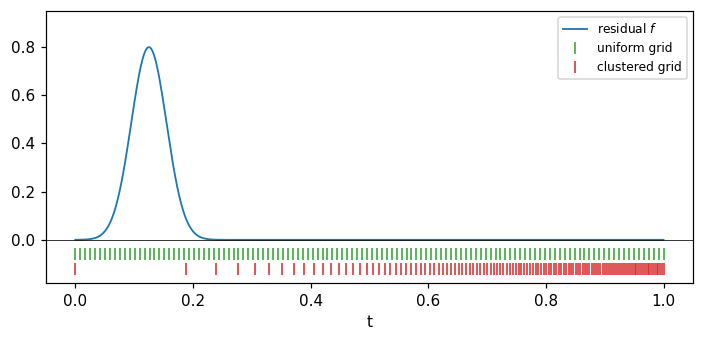

points in [0, 0.25]:  uniform 30,  clustered 3   (of 120)


In [3]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(t_fine, f_narrow, lw=1.2, color="tab:blue", label="residual $f$")
ax.plot(t_uniform,   np.full(n_keep, -0.06), "|", ms=8, color="tab:green", label="uniform grid")
ax.plot(t_clustered, np.full(n_keep, -0.12), "|", ms=8, color="tab:red",   label="clustered grid")
ax.axhline(0, lw=0.5, color="k")
ax.set_ylim(-0.18, 0.95); ax.set_xlabel("t"); ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

print(f"points in [0, 0.25]:  uniform {int((t_uniform < 0.25).sum())},"
      f"  clustered {int((t_clustered < 0.25).sum())}   (of {n_keep})")

On the uniform grid both estimators recover the reference. On the clustered grid both fail, $L^2$ included: it places 3 of 120 points in $[0,0.25]$ and the residual lives there. Weights correct the averaging of observations, not their absence, and Proposition 3 is the limiting case of what the table shows.

> Pointwise MSE and the $L^2$ integral norm diverge precisely when $f$ and the sampling are both non-uniform in time. Quadrature weighting removes the divergence over the region the grid resolves.

Both conditions hold for irregular observation with time-localised model error, the generic case in clinical measurement, sensor networks and astronomy. The robustness experiments in weeks 3 to 4 must therefore report sampling density alongside every loss value.

By §1.4 the weighted distance is the Horvitz-Thompson estimator of $\int f^2$ and MSE the unweighted one, so this is the documented failure of inverse-probability weighting: variance diverges as inclusion probabilities approach zero, and here three points represent a quarter of the domain.

> **Parallel with sFML.** The same structure as the noise-floor finding: a quantity differing between two models is invisible to the objective because the data does not separate them.

### 3.5 The same statement in the Lebesgue form

Partitioning the range rather than the domain gives the layer cake identity: with the distribution function $\mu_f(\lambda) = \big|\{t \in [0,T] : |f(t)| > \lambda\}\big|$,

$$\int_0^T |f|^p \;=\; \int_0^\infty p\,\lambda^{p-1}\,\mu_f(\lambda)\,\mathrm{d}\lambda ,$$

so $\|f\|_{L^p}$ depends on $f$ only through $\mu_f$, equivalently through the decreasing rearrangement $f^*$, since $\|f\|_{L^p} = \|f^*\|_{L^p}$. Lieb & Loss (2001), §1.13 and ch. 3.

**It is the same estimator.** Estimating $\mu_f$ from the samples the only way available, $\hat\mu(\lambda) = \sum_i w_i \mathbb{1}[|f(t_i)| > \lambda]$, and substituting,

$$\int_0^\infty p\lambda^{p-1}\hat\mu(\lambda)\,\mathrm{d}\lambda
\;=\; \sum_i w_i \int_0^{|f(t_i)|} p\lambda^{p-1}\,\mathrm{d}\lambda
\;=\; \sum_i w_i\,|f(t_i)|^p \;=\; Q_w(|f|^p) .$$

Exactly, not approximately. The weights do not disappear: measuring how long $f$ spends above a level is itself an integral in $t$, so $\hat\mu$ needs them.

**What it does give is the shortest statement of §3.1.** Both estimators are the same functional of a pushforward measure, and they differ in which measure is pushed forward:

$$\tfrac1T Q^{\mathrm{trap}}_m(f^2) \to \int |y|^2 \,\mathrm{d}\big(f_*\lambda_T\big)(y),
\qquad
\mathrm{MSE} \to \int |y|^2 \,\mathrm{d}\big(f_*\rho\big)(y) ,$$

with $\lambda_T$ normalised Lebesgue measure on $[0,T]$. The Corollary is then the statement that $f_*\lambda_T = f_*\rho$ for every $f$ iff $\rho = \lambda_T$.

**And a warning.** If the norm sees $f$ only through $\mu_f$, then it is invariant under every measure-preserving rearrangement of time: permute the path arbitrarily and $\|f\|_{L^p}$ is unchanged. Acceptable in a norm, disqualifying in a path-to-path loss, since order is the structure being learned. This is the limitation that $p$-variation (notebook 02) and signatures are introduced to remove, and the reason the project does not stop at $L^p$.

One numerical remark, not used here. The map $\lambda \mapsto \mu_f(\lambda)$ is monotone decreasing, hence of bounded variation, however rough $f$ is, so quadrature in $\lambda$ never meets the $C^2$ failure of §2. That is why level-set methods are used for genuinely rough integrands elsewhere; it buys nothing in this setting because the two estimators coincide.

## 4. Choice of $p$

On a probability space, and $[0,1]$ with Lebesgue measure is one, Lyapunov's inequality gives $\|f\|_{L^p} \le \|f\|_{L^q}$ for $p \le q$, with $\lim_{p\to\infty}\|f\|_{L^p} = \sup_t|f(t)|$. Larger $p$ concentrates the loss on the worst-behaved part of the path. Checked in `test_lp_monotonicity_in_p` and `test_sup_norm`; the $T^{1/p}$ normalisation in `integral_distance` is what makes the values comparable across $p$.

$p=2$ is adopted: it is the value comparable to MSE, and the only $p$ for which $L^p$ is a Hilbert space, which will be required once inner-product structure enters in week 3. $p=\infty$ is retained as a diagnostic.

## 5. Conclusions

**The estimator.**

$$\|f\|_{L^p}^p \;\approx\; Q^{\mathrm{trap}}_m\big(|f|^p\big) = \sum_{i=0}^N w^{\mathrm{trap}}_i\,|f(t_i)|^p ,
\qquad w^{\mathrm{trap}} \text{ as in §0.1}, \qquad p = 2 ,$$

implemented as `integral_norm(t, x, p)` and `integral_distance(t, x, y, p)`.

**Choice of weights.** With the nodes given, trapezoid has the highest degree of exactness among rules requiring no assumption on $f$ (§1.2), it is Bayes-optimal under a prior encoding continuity and nothing further (§1.5), and its weights are inverse-probability weights, hence unbiased under any sampling design (§1.5). It is the choice surviving the fewest assumptions, not an optimum: Godambe (1955) rules out an unconditional best linear unbiased estimator, equal weights minimise variance (§1.6), splines are better given differentiability, and smoothing before integrating is better given observation noise.

**Accuracy.** For $g \in C^2$ the error is $O(h^2)$ and a few hundred samples put it at $O(10^{-6})$; without $C^2$ it degrades to about $N^{-1}$ (§2). Either way it is controllable by sampling more densely.

**The finding.** Both estimators are $Q_w$; only the weights differ. With $h_m$, $\mu_m$ as in §3, for $f \in C([0,T])$,

$$h_m \to 0 \;\Longrightarrow\; \tfrac1T Q^{\mathrm{trap}}_m(f^2) \to \tfrac1T\!\int_0^T f^2 ,
\qquad
\mu_m \Rightarrow \rho\,\mathrm{d}t \;\Longrightarrow\; \underbrace{\tfrac1T Q^{\mathrm{unif}}_m(f^2)}_{\mathrm{MSE}} \to \int_0^T f^2\rho ,$$

agreeing for every $f$ iff $\rho = 1/T$ a.e. The first hypothesis constrains only the mesh; the second constrains where the nodes go. So MSE is **inconsistent** for $\frac1T\|f\|_{L^2}^2$ under non-uniform sampling, and refining does not help: the gap survives $2^{20}$ points, and at 120 points both estimators are within 0.2% of their respective limits, so the asymptotic gap is the finite-sample gap. §2 did not see this because a uniform grid makes $w^{\mathrm{unif}}$ and $w^{\mathrm{trap}}$ agree except at the endpoints. Equivalently (§3.5): both estimators are the same functional of a pushforward measure, and they push forward different measures.

**The limit of the fix.** If $\operatorname{supp} f$ misses the grid, both estimators return $0$ (Proposition 3). Weights correct how observations are averaged, never their absence. Any robustness claim must therefore report sampling density alongside the loss value.

**Consequences for the project.**

| | |
|---|---|
| use | $Q^{\mathrm{trap}}_m$ with $p=2$ in place of pointwise MSE wherever sampling is non-uniform |
| report | $n_{\mathrm{eff}}$ or an equivalent with every loss value |
| do not claim | robustness to observation noise; that needs smoothing before integrating, not implemented |
| open | a sweep in $\mathrm{KL}(\rho\,\|\,\mathrm{Unif})$ would replace §3's two grids by a curve (`docs/logbook/2026-08-09.md`) |

## 6. Position in the literature

Four strands, separating standard practice from open questions.

### 6.1 Numerical integration on non-uniform grids

§§1 and 2 are textbook: error terms and rules in Davis & Rabinowitz (1984), the periodicity degeneracy in Trefethen & Weideman (2014). The weights appear across applied fields as **density compensation factors**, most visibly in non-uniform FFT and MRI reconstruction. Their function here is to certify that the numerics are not a confounder for §3.

### 6.2 Survey sampling

The weighted estimator is Horvitz & Thompson (1952), and its bias/variance behaviour under near-zero inclusion probabilities accounts for the failure in §3.4. Three consequences:

- The correction is principled rather than heuristic, and defensible by citation.
- The failure modes are already mapped, so misbehaviour can be predicted rather than discovered.
- The variance-reduction literature (stabilised, trimmed, self-normalised weights) applies if extreme grids destabilise training.

### 6.3 Functional data analysis

Ramsay & Silverman (2005) and Ferraty & Vieu (2006) give the basis-expansion and semi-metric machinery; Wang, Chiou & Müller (2016) review.

**Zhang & Wang (2016)** show the efficiency of equal weight per observation versus equal weight per subject reverses with sampling density: per subject for dense designs, per observation for sparse. The accurate statement of §3 is therefore:

> The preferable weighting is a bias/variance tradeoff depending on the sampling regime. Quadrature weights remove a bias and can add variance. §3 exhibits a regime in which the bias dominates.

Weaker than "MSE is the wrong loss", more defensible, and citable. It also fixes what must be measured in weeks 3 to 4: variance across resamplings, not bias alone.

### 6.4 Non-pointwise losses for time series

An active literature addresses losses beyond pointwise error, on a different axis from ours:

| | corrects | mechanism |
|---|---|---|
| soft-DTW (Cuturi & Blondel, 2017) | misalignment in time | differentiable relaxation of DTW alignment |
| DILATE (Le Guen & Thome, 2019) | shape and timing jointly | soft-DTW with a temporal distortion index |
| patch-wise structural loss (Kudrat et al., 2025) | local structure lost by MSE | patch statistics rather than points |
| **quadrature weighting (this notebook)** | the measure integrated against | $w_i \approx \Delta t_i$ |

DTW assumes reliable samples and wrong correspondence; we assume correct correspondence and wrong weighting. The axes are orthogonal and compose. Signature-based losses address both: reparametrisation invariance for alignment, the integral formulation for measure.

### 6.5 Irregular sampling in machine learning

GRU-D (Che et al., 2018), Latent ODEs (Rubanova et al., 2019), mTAN (Shukla & Marlin, 2021), Neural CDEs (Kidger et al., 2020), surveyed by Shukla & Marlin (2021).

All of it modifies the model, through decay mechanisms, continuous-time dynamics, attention over time or interpolated control paths, and leaves the objective as pointwise MSE or cross-entropy. How the architecture ingests irregular samples has been addressed; what measure the loss should integrate against has not.

By §3 the gap is not cosmetic: a model well designed for irregular sampling can still be trained against an objective that re-weights the time axis by observation density.

### Summary

| section | status |
|---|---|
| §§1 and 2, quadrature | textbook; certification, not contribution |
| §3, weighting | rediscovery of Horvitz-Thompson; novelty in the application to path-to-path losses |
| §4, choice of $p$ | standard $L^p$ theory |

No new mathematics. The unoccupied intersection is **continuous-time models trained on irregularly sampled data with a loss accounting for the sampling measure**, and §3 is evidence that it is non-empty.

## Next steps

1. Port `integral_distance` to a differentiable torch loss in `src/pathloss/losses.py`, weights precomputed per batch, tested against the NumPy version.
2. Add the signature-kernel MMD using `sigkernel` and repeat §3 for it. Reparametrisation invariance predicts greater stability than the integral norm under changes of grid: a falsifiable prediction and a week 3 deliverable.
3. Repeat §3 with missingness in place of irregular sampling.
4. **Replace §3's two grids with a sweep in a scalar measure of sampling non-uniformity** (`docs/logbook/2026-08-09.md`). The divergence depends on $\rho$ only through its departure from uniformity, so $\mathrm{KL}(\rho\,\|\,\mathrm{Unif})$ is the natural abscissa, closed-form in $\alpha$ for $t = u^{\alpha}$. To be raised on Thursday.

---

## References cited in this notebook

Keyed to `papers/references.bib`. PDFs of starred items are in `papers/`.

**Quadrature and numerical integration**
- **Davis & Rabinowitz (1984)**, *Methods of Numerical Integration*: error terms, Gauss-Legendre. §1, §6.1.
- **Trefethen & Weideman (2014)**, *The exponentially convergent trapezoidal rule*, SIAM Review 56(3): the periodic degeneracy. §2, §6.1.

**Measure theory**
- **Lieb & Loss (2001)**, *Analysis*, 2nd ed.: layer cake representation §1.13, rearrangement ch. 3. §3.5.

**Weighting and estimation**
- **Horvitz & Thompson (1952)**, JASA 47(260): inverse-probability weighting. §3, §6.2.

**Functional data analysis**
- **Ferraty & Vieu (2006)**: discretised $L^2$ semi-metric, weights $w_j = t_j - t_{j-1}$. §1, §6.3.
- **Ramsay & Silverman (2005)**, ch. 3 to 5: basis expansion, Gram matrices, roughness penalties. §1, §6.3. Route not yet taken.
- **Wang, Chiou & Müller (2016)**, *Annu. Rev. Stat. Appl.* 3: FDA review. §6.3.
- **Zhang & Wang (2016)**, *Ann. Statist.* 44(5): reversal of weighting efficiency with sampling density. §6.3.

**Non-pointwise losses for time series**
- **Cuturi & Blondel (2017)**, soft-DTW, ICML. §6.4.
- **Le Guen & Thome (2019)**, DILATE, NeurIPS. §6.4.
- **Kudrat et al. (2025)**, patch-wise structural loss, ICML. §6.4.

**Irregular sampling in machine learning**
- **Che et al. (2018)**, GRU-D, *Sci. Rep.* 8. §6.5.
- **Rubanova, Chen & Duvenaud (2019)**, Latent ODEs, NeurIPS. §6.5.
- **Shukla & Marlin (2021)**, mTAN, ICLR, and survey arXiv:2012.00168. §6.5.
- **Kidger et al. (2020)**, Neural CDEs, NeurIPS. §6.5.

**Signatures**
- ★ **Salvi et al. (2021)**, *The signature kernel is the solution of a Goursat PDE*. Next steps.

